# Cortonis Pharma — Deviation & CAPA Process Mining
### Where does a CAPA actually lose its 30 days?

This notebook walks through how I found one specific thing: the KPI view that looks
totally normal, then the process reconstruction that shows what the KPI view is
missing, then a couple of numbers to size the actual cost.

All data here is synthetic. Cortonis Pharma isn't a real company. More context in the README, and the actual SOP being
compared against is `docs/SOP-QA-012_Deviation-and-CAPA-Management.docx`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.chdir("..")  # so relative paths (data/, docs/) resolve the same way the src/ modules expect

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import pm4py

from src.loader import load_event_log
from src import discovery, conformance, kpi, organizational as org

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "font.size": 10})
GREEN, RED, GRAY, AMBER = "#0B5D3B", "#B4392B", "#8A8F98", "#B4750D"
site_colors = lambda index: [RED if s == "Lyon" else GREEN for s in index]

df = load_event_log()
print(f"{df.case_id.nunique()} cases, {len(df)} events, sites: {sorted(df.site.unique())}")
df.head()



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




3000 cases, 56308 events, sites: ['Barcelona', 'Dublin', 'Frankfurt', 'Lyon', 'Milan']


,case_id,activity,timestamp,lifecycle_state,resource,site,deviation_type,severity,regulatory_deadline_days
0,DEV-2025-00001,Deviation Opened,2025-11-06 16:25:01,complete,Production Supervisor,Barcelona,Laboratory,Minor,90
1,DEV-2025-00001,Initial Assessment,2025-11-06 18:16:41,start,QA Investigator,Barcelona,Laboratory,Minor,90
2,DEV-2025-00001,Initial Assessment,2025-11-06 20:21:50,complete,QA Investigator,Barcelona,Laboratory,Minor,90
3,DEV-2025-00001,Investigation Assigned,2025-11-10 12:56:48,start,Site Quality Manager,Barcelona,Laboratory,Minor,90
4,DEV-2025-00001,Investigation Assigned,2025-11-10 14:39:15,complete,Site Quality Manager,Barcelona,Laboratory,Minor,90


## 1. Standard KPI view: average step duration by site

This is basically the report a quality manager would already have — average time
spent inside each step, per site. It doesn't tell you anything about how many times a
case had to go back through a step.

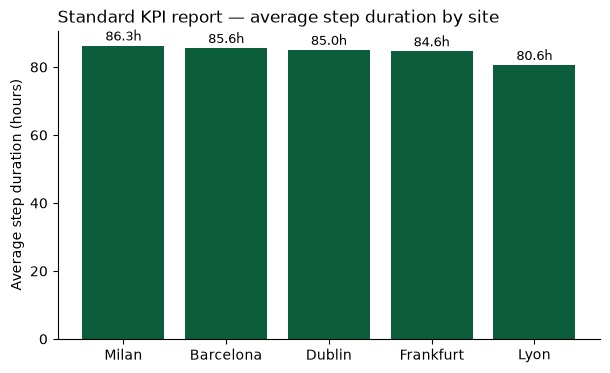

Lyon: 80.6h   network (excl. Lyon): 85.4h   delta: -5.6%


In [2]:
steps = kpi.step_durations(df)
avg_step_by_site = steps.groupby("site")["duration_hours"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(avg_step_by_site.index, avg_step_by_site.values, color=GREEN)  # uniform: nothing stands out here
for b, v in zip(bars, avg_step_by_site.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}h", ha="center", fontsize=9)
ax.set_ylabel("Average step duration (hours)")
ax.set_title("Standard KPI report — average step duration by site", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

lyon_avg = avg_step_by_site["Lyon"]
rest_avg = avg_step_by_site.drop("Lyon").mean()
print(f"Lyon: {lyon_avg:.1f}h   network (excl. Lyon): {rest_avg:.1f}h   delta: {(lyon_avg/rest_avg - 1) * 100:+.1f}%")

Lyon is right in the middle here. Nothing in this chart would make anyone look twice.

## 2. But total cycle time looks different

Same sites, same data, just looking at total time from opening to closing instead —
regardless of which steps got visited or how many times.

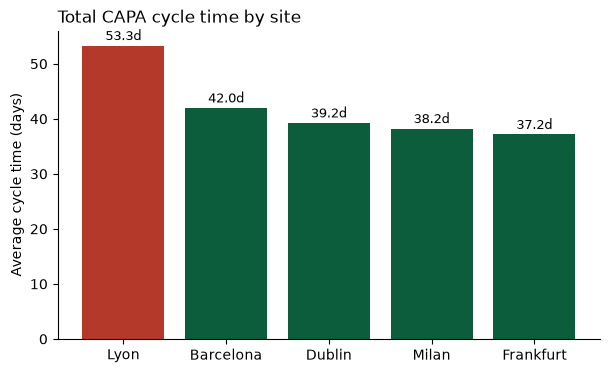

Lyon: 53.3 days   Frankfurt/Milan/Dublin baseline: 38.1 days   delta: +39.8%


In [3]:
cycle = kpi.case_cycle_time(df)
mean_cycle = cycle.groupby("site")["cycle_time_days"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(mean_cycle.index, mean_cycle.values, color=site_colors(mean_cycle.index))
for b, v in zip(bars, mean_cycle.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}d", ha="center", fontsize=9)
ax.set_ylabel("Average cycle time (days)")
ax.set_title("Total CAPA cycle time by site", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

baseline = cycle[cycle.site.isin(["Frankfurt", "Milan", "Dublin"])]["cycle_time_days"].mean()
lyon_mean = mean_cycle["Lyon"]
print(f"Lyon: {lyon_mean:.1f} days   Frankfurt/Milan/Dublin baseline: {baseline:.1f} days   "
      f"delta: {(lyon_mean/baseline - 1) * 100:+.1f}%")

Same step durations, but ~40% longer overall for Lyon. So the two views disagree, and the average-duration KPI can't explain why. That's the gap process mining can actually answer.

## 3. Reconstructing what actually happened

A Directly-Follows Graph (DFG) from PM4Py shows the actual order activities happened
in across the log — not the order the SOP describes.

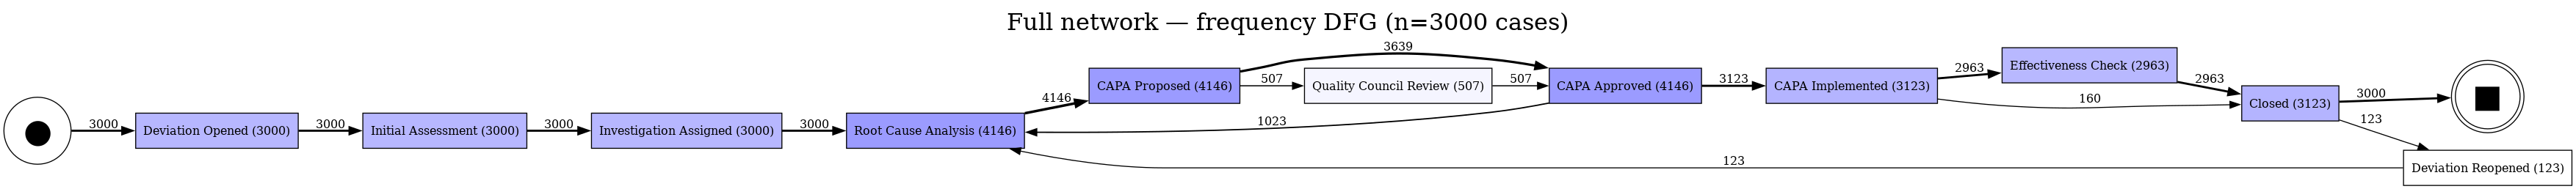

In [4]:
dfg, sa, ea = discovery.discover_dfg_frequency(df)
pm4py.save_vis_dfg(dfg, sa, ea, "_dfg_full.png",
                    graph_title=f"Full network — frequency DFG (n={df.case_id.nunique()} cases)")
display(Image("_dfg_full.png"))

In [5]:
variants = discovery.get_case_variants(df)
print(f"{len(variants)} distinct variants across {df.case_id.nunique()} cases\n")
for v in variants[:5]:
    print(f"{v['count']:>5}  ({v['frequency']*100:5.1f}%)  " + " -> ".join(v["variant"]))

28 distinct variants across 3000 cases

 1838  ( 61.3%)  Deviation Opened -> Initial Assessment -> Investigation Assigned -> Root Cause Analysis -> CAPA Proposed -> CAPA Approved -> CAPA Implemented -> Effectiveness Check -> Closed
  379  ( 12.6%)  Deviation Opened -> Initial Assessment -> Investigation Assigned -> Root Cause Analysis -> CAPA Proposed -> CAPA Approved -> Root Cause Analysis -> CAPA Proposed -> CAPA Approved -> CAPA Implemented -> Effectiveness Check -> Closed
  267  (  8.9%)  Deviation Opened -> Initial Assessment -> Investigation Assigned -> Root Cause Analysis -> CAPA Proposed -> Quality Council Review -> CAPA Approved -> CAPA Implemented -> Effectiveness Check -> Closed
  115  (  3.8%)  Deviation Opened -> Initial Assessment -> Investigation Assigned -> Root Cause Analysis -> CAPA Proposed -> CAPA Approved -> CAPA Implemented -> Closed
  112  (  3.7%)  Deviation Opened -> Initial Assessment -> Investigation Assigned -> Root Cause Analysis -> CAPA Proposed -> CAPA Ap

You can already see it in the variant list: the 2nd most common variant is just the happy path with one extra loop through `Root Cause Analysis -> CAPA Proposed -> CAPA Approved` — a CAPA that got rejected and sent back. Let's check if that loop shows up more at Lyon.

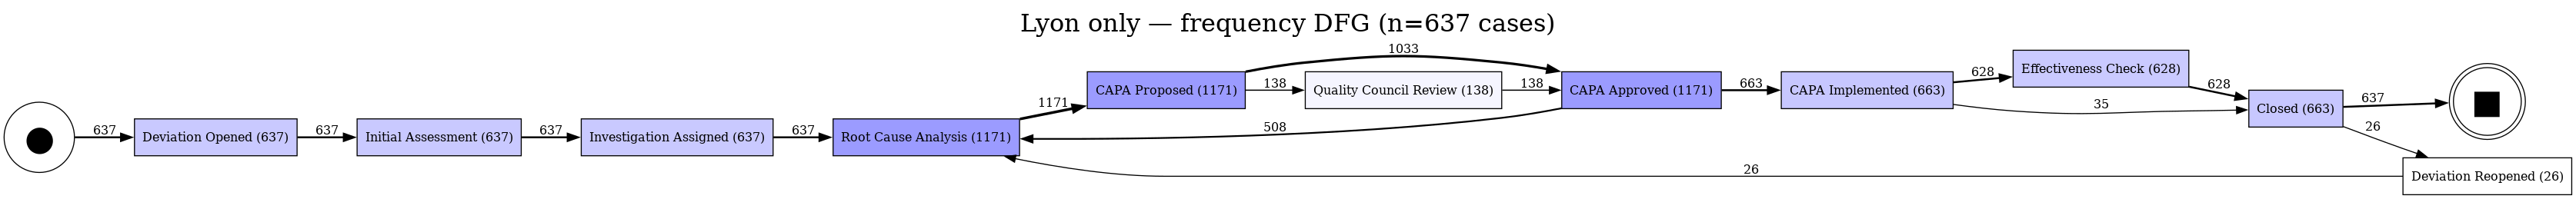

'CAPA Approved -> Root Cause Analysis' occurrences per case: network 0.34, Lyon 0.80 (2.3x)


In [6]:
lyon_df = df[df.site == "Lyon"]
dfg_lyon, sa_lyon, ea_lyon = discovery.discover_dfg_frequency(lyon_df)
pm4py.save_vis_dfg(dfg_lyon, sa_lyon, ea_lyon, "_dfg_lyon.png",
                    graph_title=f"Lyon only — frequency DFG (n={lyon_df.case_id.nunique()} cases)")
display(Image("_dfg_lyon.png"))

loop = ("CAPA Approved", "Root Cause Analysis")
loop_rate_full = dfg.get(loop, 0) / df.case_id.nunique()
loop_rate_lyon = dfg_lyon.get(loop, 0) / lyon_df.case_id.nunique()
print(f"'{loop[0]} -> {loop[1]}' occurrences per case: "
      f"network {loop_rate_full:.2f}, Lyon {loop_rate_lyon:.2f} ({loop_rate_lyon/loop_rate_full:.1f}x)")

## 4. Conformance checking against SOP-QA-012

Token-based replay against the plain SOP flow in `data/sop_reference.json` (no rework
branch) turns "the graph looks busier at Lyon" into an actual number — % of cases that
match the SOP exactly.

replaying log with TBR, completed traces ::   0%|          | 0/28 [00:00<?, ?it/s]

replaying log with TBR, completed traces :: 100%|██████████| 28/28 [00:00<00:00, 636.74it/s]

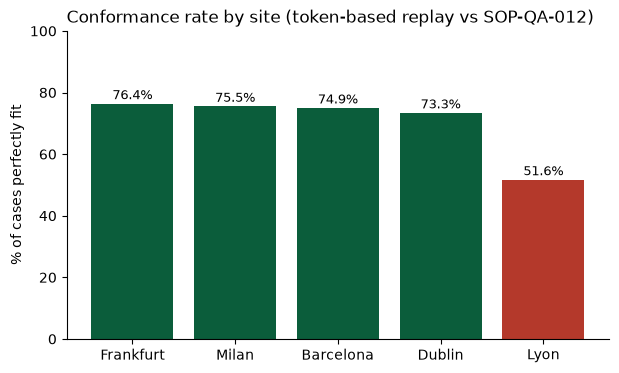

Overall conformance rate: 70.2%   average fitness: 0.970
Most frequent fitness problem activities: [('Root Cause Analysis', 780), ('Closed', 159)]
Out-of-model activity rates (governed outside SOP-QA-012, not fitness violations): {'Quality Council Review': '12.1%', 'Deviation Reopened': '4.1%'}


In [7]:
net, im, fm, flow = conformance.build_reference_net()
conf_df = conformance.check_conformance(df, net, im, fm, flow)
summary = conformance.conformance_summary(conf_df)

rate_by_site = (conf_df.groupby("site")["fit"].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rate_by_site.index, rate_by_site.values, color=site_colors(rate_by_site.index))
for b, v in zip(bars, rate_by_site.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("% of cases perfectly fit")
ax.set_title("Conformance rate by site (token-based replay vs SOP-QA-012)", loc="left")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(f"Overall conformance rate: {summary['conformance_rate']*100:.1f}%   "
      f"average fitness: {summary['average_fitness']:.3f}")
print("Most frequent fitness problem activities:", summary["most_frequent_problem_activities"])
print("Out-of-model activity rates (governed outside SOP-QA-012, not fitness violations):",
      {k: f"{v*100:.1f}%" for k, v in summary["out_of_model_activity_rates"].items()})

`Root Cause Analysis` and `Closed` show up the most as fitness problems — that's rework loops and skipped Effectiveness Checks. `Quality Council Review` and `Deviation Reopened` are tracked separately instead, since they're not even in the reference model (SOP section 9 says they're handled outside the main procedure), so it wouldn't really be fair to count them as violations.

## 5. Putting a number on it

Two KPIs to turn "more rework" into something concrete: how much time is actually
spent inside rejection loops, and how often that pushes a case past its regulatory
deadline.

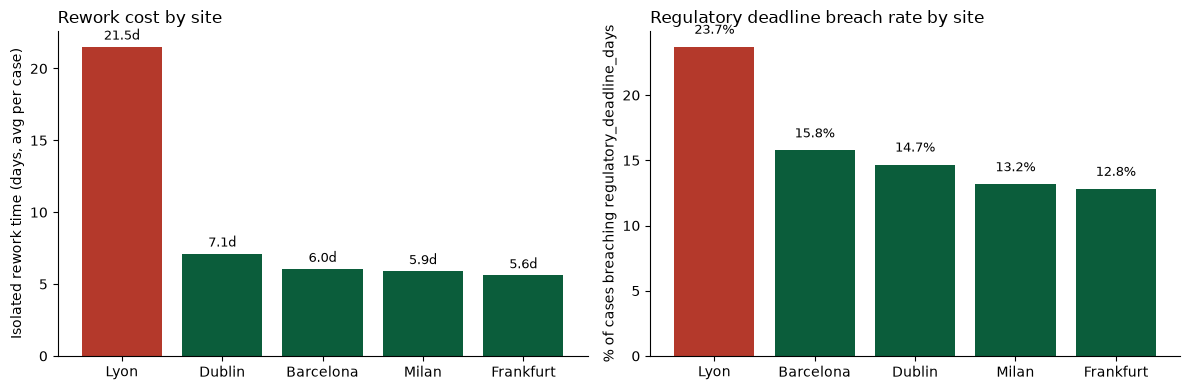

Isolated rework time -- Lyon: 21.5d   non-Lyon avg: 6.1d


In [8]:
rework = kpi.rework_time(df)
mean_rework = rework.groupby("site")["rework_time_days"].mean().sort_values(ascending=False)

breach = kpi.deadline_breach(df)
breach_rate = breach.groupby("site")["breached"].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(mean_rework.index, mean_rework.values, color=site_colors(mean_rework.index))
for b, v in zip(bars, mean_rework.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}d", ha="center", fontsize=9)
axes[0].set_ylabel("Isolated rework time (days, avg per case)")
axes[0].set_title("Rework cost by site", loc="left")
axes[0].spines[["top", "right"]].set_visible(False)

bars = axes[1].bar(breach_rate.index, breach_rate.values, color=site_colors(breach_rate.index))
for b, v in zip(bars, breach_rate.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylabel("% of cases breaching regulatory_deadline_days")
axes[1].set_title("Regulatory deadline breach rate by site", loc="left")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Isolated rework time -- Lyon: {mean_rework['Lyon']:.1f}d   "
      f"non-Lyon avg: {rework[rework.site != 'Lyon'].rework_time_days.mean():.1f}d")

## 6. Everything together

Same finding, four different angles — KPI, discovery, conformance, organizational.
None of these modules know "Lyon" is the site to look at, they just all land on it anyway.

In [9]:
non_lyon_step = avg_step_by_site.drop("Lyon").mean()
non_lyon_cycle = cycle[cycle.site != "Lyon"]["cycle_time_days"].mean()
non_lyon_rework = rework[rework.site != "Lyon"]["rework_time_days"].mean()
non_lyon_conf = conf_df[conf_df.site != "Lyon"]["fit"].mean() * 100

summary_table = pd.DataFrame([
    {"Metric": "Average step duration (h)", "Lyon": f"{avg_step_by_site['Lyon']:.1f}", "Network": f"{non_lyon_step:.1f}", "Delta": f"{(avg_step_by_site['Lyon']/non_lyon_step - 1)*100:+.1f}%"},
    {"Metric": "Average cycle time (days)", "Lyon": f"{mean_cycle['Lyon']:.1f}", "Network": f"{non_lyon_cycle:.1f}", "Delta": f"{(mean_cycle['Lyon']/non_lyon_cycle - 1)*100:+.1f}%"},
    {"Metric": "Isolated rework time (days)", "Lyon": f"{mean_rework['Lyon']:.1f}", "Network": f"{non_lyon_rework:.1f}", "Delta": f"{(mean_rework['Lyon']/non_lyon_rework - 1)*100:+.1f}%"},
    {"Metric": "Conformance rate", "Lyon": f"{rate_by_site['Lyon']:.1f}%", "Network": f"{non_lyon_conf:.1f}%", "Delta": f"{rate_by_site['Lyon'] - non_lyon_conf:+.1f}pp"},
])
summary_table

,Metric,Lyon,Network,Delta
0,Average step duration (h),80.6,85.4,-5.6%
1,Average cycle time (days),53.3,38.9,+36.9%
2,Isolated rework time (days),21.5,6.1,+252.8%
3,Conformance rate,51.6%,75.2%,-23.5pp


## 7. One more thing: Barcelona

There's a second, separate anomaly in the data, mostly as a check that I wasn't just
seeing what I expected to see. Organizational mining picks it up from a different
angle entirely: how long a role waits before starting work on a case.

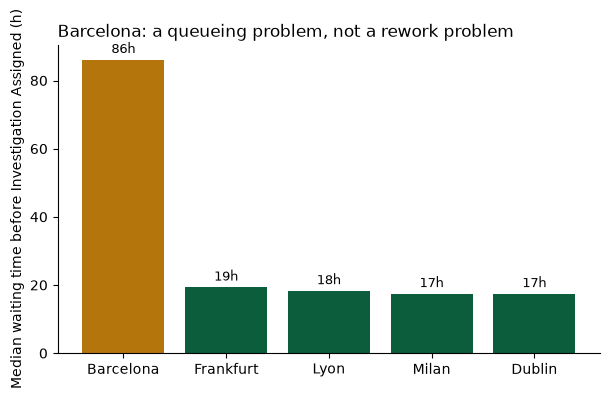

In [10]:
wait = org.waiting_time_by_role(df)
inv_wait = wait[wait.activity == "Investigation Assigned"]
wait_by_site = inv_wait.groupby("site")["waiting_hours"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [AMBER if s == "Barcelona" else GREEN for s in wait_by_site.index]
bars = ax.bar(wait_by_site.index, wait_by_site.values, color=colors)
for b, v in zip(bars, wait_by_site.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 2, f"{v:.0f}h", ha="center", fontsize=9)
ax.set_ylabel("Median waiting time before Investigation Assigned (h)")
ax.set_title("Barcelona: a queueing problem, not a rework problem", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Barcelona's cases wait a lot longer before `Investigation Assigned` actually starts — looks like a staffing/queue issue, not a rework issue like Lyon. Different problem, different fix, and this metric alone wouldn't have caught what's going on with Lyon.

## Wrapping up

> *Lyon's average step duration is in line with the network. Its CAPA cycle time is 40%
> longer. Standard reporting cannot explain the gap — process mining can.*

Everything above just used the raw event log and the five `src/` modules (`loader`,
`discovery`, `conformance`, `kpi`, `organizational`). Those same modules are what the
Streamlit app (`app/streamlit_app.py`) will wrap in an interactive UI with filters —
this notebook is really just the narrated, one-off version of that.